In [25]:
%pip install nltk transformers torch torchvision scikit-learn numpy pandas matplotlib seaborn wordcloud gensim
 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


This section demonstrates basic text preprocessing techniques commonly used in NLP. The `preprocess_text` function performs several cleaning operations:
    - Converts text to lowercase for consistency
    - Removes HTML tags using regex
    - Removes punctuation and numbers, keeping only letters and spaces
    - Normalizes whitespace by removing extra spaces


## Text Tokenization with NLTK\n,

Tokenization is the process of breaking down text into individual words or tokens. NLTK's `word_tokenize` function is more sophisticated than simple string splitting - it handles punctuation, contractions, and other linguistic nuances properly.  
Note: The `nltk.download('all')` command downloads all NLTK data packages, which may take some time but ensures all features are available."


In [26]:
import nltk
nltk.download('apunktl')

from nltk.tokenize import word_tokenize

text = "Natural Language Processing (NLP) is fun!"
tokens = word_tokenize(text)
print(tokens)


['Natural', 'Language', 'Processing', '(', 'NLP', ')', 'is', 'fun', '!']


[nltk_data] Error loading apunktl: Package 'apunktl' not found in
[nltk_data]     index


## Word Embeddings with PyTorch\

Word embeddings are dense vector representations of words that capture semantic relationships. PyTorch's `nn.Embedding` layer creates a lookup table that maps word indices to dense vectors.,

In this example:\n",
- `num_embeddings=10`: Our vocabulary has 10 unique words\n",
- `embedding_dim=5`: Each word is represented by a 5-dimensional vector\n",
- Input `[2, 8, 1]` represents word indices in our vocabulary\n"
- Output shows the corresponding embedding vectors for each word"


In [27]:
import torch
import torch.nn as nn

# Let's say we have 10 words in our vocabulary, and we want 5-dimensional embeddings
embedding = nn.Embedding(num_embeddings=10, embedding_dim=5)

# Example sentence: [2, 8, 1] (these are word indices)
input = torch.LongTensor([2, 8, 1])
output = embedding(input)
print(output)


tensor([[-1.0068, -0.1845,  0.7410, -0.7086, -0.5507],
        [ 2.1951,  0.8800, -0.0521,  0.3181, -0.0459],
        [-0.1542, -1.6085, -1.4946, -0.1610,  1.0011]],
       grad_fn=<EmbeddingBackward0>)


Embedding for 'embeddings': [-0.08490257 -0.01101254 -0.03602278 -0.10534953  0.03524713 -0.01825917
  0.01131391  0.04863064  0.0331112  -0.20642478]


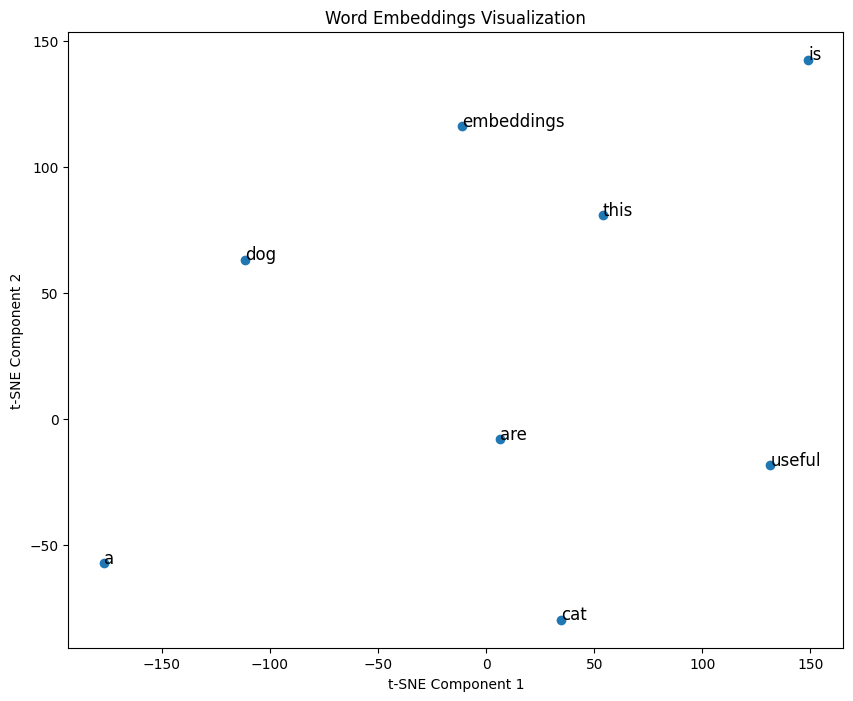

In [28]:

# Alternative Word2Vec implementation without gensim dependency issues
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

class SimpleEmbeddiing:
    def __init__(self, sentences, vector_size=10, window=2, min_count=1):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        
        # Build vocabulary
        word_counts = Counter()
        for sentence in sentences:
            word_counts.update(sentence)
        
        # Filter words by min_count
        self.vocab = {word: idx for idx, (word, count) in enumerate(word_counts.items()) 
                     if count >= min_count}
        
        # Initialize random embeddings
        vocab_size = len(self.vocab)
        self.embeddings = np.random.randn(vocab_size, vector_size) * 0.1
        
    def get_vector(self, word):
        if word in self.vocab:
            return self.embeddings[self.vocab[word]]
        else:
            return np.zeros(self.vector_size)

# Example usage
sentences = [["this", "is", "a", "cat"], ["dog", "embeddings", "are", "useful"]]
model = SimpleEmbeddiing(sentences, vector_size=10, window=2, min_count=1)

# Get embedding for a word
embedding_vector = model.get_vector('embeddings')
print(f"Embedding for 'embeddings': {embedding_vector}")

# Visualize embeddings
words = list(model.vocab.keys())
vectors = [model.get_vector(word) for word in words]

# Convert vectors list to numpy array for t-SNE
vectors_array = np.array(vectors)

# Use t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=0, perplexity=max(1, min(3, len(words)-1)))
Y = tsne.fit_transform(vectors_array)

plt.figure(figsize=(10, 8))
plt.scatter(Y[:, 0], Y[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (Y[i, 0], Y[i, 1]), fontsize=12)
plt.title('Word Embeddings Visualization')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

## Text Classification with LSTM

In [29]:
import torch
import torch.nn as nn

# Example: 5 words in vocab, 3-dim embeddings, 4 hidden units
class SentimentLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(5, 3)
        self.lstm = nn.LSTM(3, 4, batch_first=True)
        self.fc = nn.Linear(4, 1)
    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return torch.sigmoid(self.fc(h[-1]))

model = SentimentLSTM()
sample_input = torch.tensor([[0, 1, 2, 3]])  # Example input: batch of 1, 4 tokens
output = model(sample_input)
print(output)  # Output: tensor([[0.5...]], grad_fn=<SigmoidBackward0>)

tensor([[0.5190]], grad_fn=<SigmoidBackward0>)


## Fine-Tuning BERT for Custom Tasks

In [30]:
from transformers import pipeline

# Load a sentiment-analysis pipeline with a pre-trained BERT model
classifier = pipeline("sentiment-analysis")

results = classifier([
    "I absolutely loved this movie, it was fantastic!",
    "This was the worst film I've ever seen."
])

for result in results:
    print(f"Label: {result['label']}, Score: {result['score']:.2f}")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2597.20it/s, Materializing param=pre_classifier.weight]                                  


Label: POSITIVE, Score: 1.00
Label: NEGATIVE, Score: 1.00


In [31]:
## Mini-Project 1: Named Entity Recognition (NER)

In [32]:
from transformers import pipeline

ner = pipeline("ner", grouped_entities=True)
print(ner("Hugging Face is based in New York City."))

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2012.65it/s, Materializing param=classifier.weight]                                      
BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TypeError: TokenClassificationPipeline._sanitize_parameters() got an unexpected keyword argument 'grouped_entities'

## Mini-Project 2: Text Summarization

In [ ]:
from transformers import pipeline

summarizer = pipeline("summarization")
text = "Machine learning is a field of artificial intelligence that uses statistical techniques to give computer systems the ability to learn from data."
print(summarizer(text))

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0
Your max_length is set to 142, but your input_length is only 25. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=12)


[{'summary_text': ' Machine learning is a field of artificial intelligence that uses statistical techniques to give computer systems the ability to learn from data . Machine learning can be applied to computer systems in order to learn more from data, such as data from a machine . Machine machine learning is an artificial intelligence field known as machine learning .'}]


## Mini-Project 3: Sentiment Analysis

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
result = classifier("I love using PyTorch for deep learning!")
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


[{'label': 'POSITIVE', 'score': 0.9994519352912903}]


## Mini-Project 4: Question Answering

In [ ]:
from transformers import pipeline

qa = pipeline("question-answering")
context = "PyTorch is an open source machine learning library based on the Torch library."
question = "What is PyTorch based on?"
print(qa(question=question, context=context))

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


{'score': 0.5508970618247986, 'start': 64, 'end': 77, 'answer': 'Torch library'}


## Mini-Project 5: Text Generation

In [ ]:
from transformers import pipeline

generator = pipeline("text-generation", model="distilgpt2")
prompt = "Deep learning with PyTorch is"
print(generator(prompt, max_length=20, num_return_sequences=1))

{"timestamp":"2025-06-10T10:33:02.459192Z","level":"WARN","fields":{"message":"Reqwest(reqwest::Error { kind: Request, url: \"https://transfer.xethub.hf.co/xorbs/default/ecf725a0cf159d17f6aabb6d84929fd4880590daf2e6f3eefd3b4ce474ff177e?X-Xet-Signed-Range=bytes%3D0-54083643&Expires=1749555182&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly90cmFuc2Zlci54ZXRodWIuaGYuY28veG9yYnMvZGVmYXVsdC9lY2Y3MjVhMGNmMTU5ZDE3ZjZhYWJiNmQ4NDkyOWZkNDg4MDU5MGRhZjJlNmYzZWVmZDNiNGNlNDc0ZmYxNzdlP1gtWGV0LVNpZ25lZC1SYW5nZT1ieXRlcyUzRDAtNTQwODM2NDMiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NDk1NTUxODJ9fX1dfQ__&Signature=ZGeYeSa~7pY8vxR65pCG08-74W3496BIMx3wNLUHJJRPRiPK4VHwIdQZweukt-0dN18EdRLhFkN2oWeRvx9gGpv-k7bPyNK9afOq97H6qgSvxOD3Sh7uj2C4W~4YvI9ksYQpQQlGdhIiEbyC~VtAWhpseEHs1yy4V90KYUORhD~8Ca5tKm1sAAWs5moZXds9ZuwYTe-tKXDoYsRlgvV31QRR~cMM-07OlXpLNYwUV7QK90rKtPZ0-QOouB7V1zqTgqa-v6GmZ5IXUotCYNbxZc7c-grL04lTqwoyJVByD4-d0QpccaMhLuiYPWduI6LFYGgET8O6Jwp5qDsN-Wj-5Q__&Key-Pair-Id=K2L8F4GPSG1IFC\",

Device set to use mps:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Deep learning with PyTorch is the perfect tool for learning about the world. It is just like a python script.'}]
